In [1]:
import torch
import pprint
lam_path: str = "/mnt/mnt/public/chenjl/code/UniVLA/latent_action_model/logs/vjepa_lam/epoch=14-step=20000.ckpt"

In [2]:
lam_ckpt = torch.load(lam_path, map_location="cpu")['state_dict']

for k, v in lam_ckpt.items():
    print(k)


/tmp/ipykernel_3083509/917989657.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lam_ckpt = torch.load(lam_path, map_location="cpu")['state_dict']

KeyboardInterrupt



In [ ]:
import tensorflow

2025-09-19 13:18:11.903219: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-19 13:18:11.941236: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-19 13:18:11.941273: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-19 13:18:11.942145: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-19 13:18:11.947699: I tensorflow/core/platform/cpu_feature_guar

In [ ]:
print(tensorflow.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
!export HF_HOME="/mnt/public_zgc/home/jlchen/.cache/huggingface"
!export HF_HUB_CACHE="/mnt/public_zgc/home/jlchen/.cache/huggingface/models"
!export HF_DATASETS_CACHE="/mnt/public_zgc/home/jlchen/.cache/huggingface/datasets"
from transformers import AutoVideoProcessor, AutoModel

hf_repo = "facebook/vjepa2-vith-fpc64-256"

model = AutoModel.from_pretrained(hf_repo, force_download=True)
processor = AutoVideoProcessor.from_pretrained(hf_repo)


2025-09-22 12:46:04.810409: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-22 12:46:05.340166: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-22 12:46:05.340226: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-22 12:46:05.404927: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-22 12:46:05.566404: I tensorflow/core/platform/cpu_feature_guar

ValueError: Force download failed due to the above error.

In [3]:
import json
import os
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Optional, Tuple, Union, Dict, Any
from datetime import datetime

import torch
import torch.distributed as dist
import yaml
from latent_action_model.core.lam_model import load_latent_action_model
from prismatic.overwatch import initialize_overwatch
from prismatic.util import set_global_seed
from prismatic.vla import get_latent_vla_dataset_and_collator
from prismatic.vla.datasets.datasets import RLDSDataset
from prismatic.models import load_InternVL,freeze_internvl
from prismatic.vla.datasets.rlds.utils.data_utils import save_dataset_statistics
from typing import cast
from prismatic.training.accelerate_fsdp_trainer import run_latent_action_training
from prismatic.vla.latent_vla_model import LatentVLAModel
from transformers import AutoProcessor

# Sane Defaults
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")


# Initialize Overwatch =>> Wraps `logging.Logger`
overwatch = initialize_overwatch(__name__)

# 📝 动作 token 列表: ['<ACT_0>', '<ACT_1>', '<ACT_2>', '<ACT_3>', '<ACT_4>', '<ACT_5>', '<ACT_6>', '<ACT_7>', '<ACT_8>', '<ACT_9>', '<ACT_10>', '<ACT_11>', '<ACT_12>', '<ACT_13>', '<ACT_14>', '<ACT_15>']
# 🔢 对应的 token ID: [151679, 151680, 151681, 151682, 151683, 151684, 151685, 151686, 151687, 151688, 151689, 151690, 151691, 151692, 151693, 151694]
# 🎯 action_token_begin_id = 151679
# 📊 ID 范围: 151679 - 151694
home_path = "/mnt/project_rlinf/jlchen"

@dataclass
class TrainConfig:
    # fmt: off

    # =========================
    # 路径与资源
    # =========================
    # Directory Paths
    data_root_dir: Path = Path(home_path + "/datasets")
    run_root_dir: Path = Path("vla_log")    # Store logs & checkpoints under vla_scripts/

    # Hugging Face 模型标识（或本地权重目录）；用于 PrismaticVLM.from_pretrained()
    # model_id: str = home_path + "/weights/InternVL3_5-1B-Instruct-HF"
    model_id: str = home_path + "/weights/Qwen3-VL-2B-Instruct"
    hf_cache_dir: Optional[Path] = None
    # =========================
    # 数据与预处理
    # =========================
    # 数据混合与缓冲
    data_mix: str = "lam_plus"
    training_phase: str = "pre-training"
    shuffle_buffer_size: int = 2000
    image_aug: bool = True                                          # Whether to enable image augmentations
    # DataLoader
    dataloader_num_workers: int = 0
    dataloader_pin_memory: bool = True

    # =========================
    # 模型冻结策略
    # =========================
    # 冻结策略
    freeze_vision_backbone: bool = False
    freeze_llm_backbone: bool = False
    freeze_last_llm_layer: bool = False
    freeze_projector: bool = False

    # =========================
    # LAM / 动作离散参数
    # =========================
    latent_action_placeholder_token: str = "<ACT_PH>"
    enable_lam_encoder_distill: bool = False
    enable_lam_decoder_perceptual: bool = False
    lam_encoder_distill_weight: float = 1.0
    lam_decoder_perceptual_weight: float = 0.0
    new_token_lr_scale: float = 1.0  # 对新增 special tokens 的 embedding 梯度放大倍数（>1 放大，=1 不变）
    use_latent_vla_model: bool = True

    # =========================
    # 训练设置
    # =========================
    # 训练超参
    debug_repeat_batch: bool = False
    epochs: Optional[int] = 10
    max_steps: Optional[int] = 20000  #以max_steps为准，若为空则按epochs * 10000近似
    per_device_batch_size: int = 256
    gradient_accumulation_steps: int = 1
    learning_rate: float = 2e-3
    warmup_steps: int = 1000
    weight_decay: float = 0.0
    max_grad_norm: float = 1.0
    lr_scheduler_type: str = "constant"   #constant_with_warmup
    optim: str = "adamw_torch"
    # 训练加速
    enable_mixed_precision_training: bool = True
    seed: int = 42                                                  # Random seed (for reproducibility)
    logging_steps: int = 1

    # =========================
    # 评估与保存
    # =========================
    eval_strategy: str = "steps"
    save_total_limit: int = -1
    eval_interval: int = 4
    eval_accumulation_steps: int = 1
    per_device_eval_batch_size: int = 128
    save_interval: int = 1000                                    # Interval for saving checkpoints (in steps

    # =========================
    # 分布式 / FSDP
    # =========================
    fsdp: Optional[str] = "full_shard"                     # 示例："full_shard auto_wrap" 或 None 关闭
    fsdp_config: Optional[Dict[str, Any]] = None   # 示例：{"fsdp_min_num_params": 1e7, "xla": False}

    # =========================
    # 运行与日志
    # =========================
    # Run Arguments
    run_id: Optional[str] = None                                  # Run ID for logging, Weights & Biases
    run_id_note: Optional[str] = "run_01"                               # Extra note for logging, Weights & Biases
    # Tracking Parameters
    wandb_project: str = "vla_pretraining"                   # Name of W&B project to log to (use default!)
    wandb_entity: Optional[str] = None                              # Name of entity to log under

    # =========================
    # 恢复 / 断点（仅用于日志标记，不再用于模型权重加载）
    # =========================
    # Resume (logging) Parameters -- 仅用于日志标记，不再用于模型权重加载
    resume_step: Optional[int] = None
    resume_epoch: Optional[int] = None

    # =========================
    # HF Hub 凭据（如有门限模型）
    # =========================
    # HF Hub Credentials (for any gated models)
    hf_token: Optional[str] = None

    # fmt: on

cfg = TrainConfig()

overwatch.info("OpenVLA Training :: Warming Up")

# Note => Under `torchrun` initializing `overwatch` will automatically set up `torch.distributed`
torch.cuda.set_device(1)
device_id = 1
torch.cuda.empty_cache()

# Configure Unique Run Name & Save Directory
vla_tag = f"{cfg.model_id.split('/')[-1]}+{cfg.data_mix}"
world_size = overwatch.world_size() if dist.is_initialized() else max(torch.cuda.device_count(), 1)
overwatch.info(f"Detected world_size = {world_size}")

cfg.run_id = (
    f"{vla_tag}+n{world_size}+b{cfg.per_device_batch_size}+x{cfg.seed}"
    if cfg.run_id is None
    else cfg.run_id
)
if cfg.run_id_note is not None:
    cfg.run_id += f"--{cfg.run_id_note}"
if cfg.image_aug:
    cfg.run_id += "--image_aug"

# Start =>> Build Directories and Set Randomness
overwatch.info('"Do or do not; there is no try."', ctx_level=1)
hf_token = str(cfg.hf_token) if isinstance(cfg.hf_token, Path) else cfg.hf_token
worker_init_fn = set_global_seed(cfg.seed, get_worker_init_fn=True)

# 统一时间戳并广播，确保所有进程共用同一目录
if dist.is_initialized():
    if overwatch.is_rank_zero():
        ts: Optional[str] = datetime.now().strftime("%m%d_%H%M%S")
    else:
        ts = None
    obj_list = [ts]
    dist.broadcast_object_list(obj_list, src=0)
    timestamp = obj_list[0]
    assert isinstance(timestamp, str)
else:
    timestamp = datetime.now().strftime("%m%d_%H%M%S")

run_dir_name = f"{timestamp}+{cfg.run_id}"
run_dir = (cfg.run_root_dir / run_dir_name)

# 仅 rank0 创建目录，其余进程等待
if dist.is_initialized():
    dist.barrier()


# 加载 processor 用于数据处理
processor = AutoProcessor.from_pretrained(cfg.model_id, trust_remote_code=True)
tokenizer = processor.tokenizer
special_tokens_dict = {"additional_special_tokens": [f"<ACT_{i}>" for i in range(32)]}
try:
    tokenizer.add_special_tokens(special_tokens_dict)  # type: ignore[attr-defined]
except Exception:
    pass
placeholder_token = getattr(cfg, "latent_action_placeholder_token", "<ACT_PH>")
try:
    tokenizer.add_special_tokens({"additional_special_tokens": [placeholder_token]})  # type: ignore[attr-defined]
except Exception:
    pass
# 获取 placeholder_token_id
tokenizer = processor.tokenizer
# placeholder_token_id = tokenizer.convert_tokens_to_ids(cfg.latent_action_placeholder_token)


train_dataset, val_dataset, collator = get_latent_vla_dataset_and_collator(
    cfg.data_root_dir,
    cfg.data_mix,
    processor=processor,
    shuffle_buffer_size=cfg.shuffle_buffer_size,
    image_aug=cfg.image_aug,
    training_phase=cfg.training_phase,
    latent_action_num_queries=4,
    debug_repeat_batch=cfg.debug_repeat_batch,
    target_seq_len=200
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")

[*] OpenVLA Training :: Warming Up
[*] Detected world_size = 2
    |=> "Do or do not; there is no try."
Load dataset info from /mnt/project_rlinf/jlchen/datasets/libero_90_rlds/1.0.0
Constructing tf.data.Dataset liber_o90 for split all, from /mnt/project_rlinf/jlchen/datasets/libero_90_rlds/1.0.0
2025-12-16 13:39:31.052086: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
[*] Loading existing dataset statistics from /mnt/project_rlinf/jlchen/datasets/libero_90_rlds/1.0.0/dataset_statistics_cce90897a62ebb09679b86ddb65828813515acaade1a05726e6abd740656daeb.json.
Constructing tf.data.Dataset liber_o90 for split train[:95%], from /mnt/project_rlinf/jlchen/datasets/libero_90_rlds/1.0.0
2025-12-16 13:39:31.259389: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
Load dataset info from /mnt/project_rlinf/jlchen/datasets/droid/1.0.0
Constructing tf.data.Dataset r2d2_faceblur f


######################################################################################
# Loading the following 7 datasets (incl. sampling weight):                         #
# libero_90_rlds: ==========================================================0.039610 #
# droid: ===================================================================0.372874 #
# bridge_dataset: ==========================================================0.147214 #
# fractal20220817_data: ====================================================0.391538 #
# taco_play: ===============================================================0.008197 #
# jaco_play: ===============================================================0.002687 #
# ego4d: ===================================================================0.037881 #
######################################################################################



Load dataset info from /mnt/project_rlinf/jlchen/datasets/droid/1.0.0
Constructing tf.data.Dataset r2d2_faceblur for split train[:95%], from /mnt/project_rlinf/jlchen/datasets/droid/1.0.0
2025-12-16 13:39:36.423063: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
Load dataset info from /mnt/project_rlinf/jlchen/datasets/bridge_dataset/1.0.0
Constructing tf.data.Dataset bridge_dataset for split train, from /mnt/project_rlinf/jlchen/datasets/bridge_dataset/1.0.0
2025-12-16 13:39:36.997084: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
Load dataset info from /mnt/project_rlinf/jlchen/datasets/fractal20220817_data/1.0.0
Constructing tf.data.Dataset fractal20220817_data for split train[:95%], from /mnt/project_rlinf/jlchen/datasets/fractal20220817_data/1.0.0
2025-12-16 13:39:37.995816: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replica


######################################################################################
# Loading the following 7 datasets (incl. sampling weight):                         #
# libero_90_rlds: ==========================================================0.039610 #
# droid: ===================================================================0.372874 #
# bridge_dataset: ==========================================================0.147214 #
# fractal20220817_data: ====================================================0.391538 #
# taco_play: ===============================================================0.008197 #
# jaco_play: ===============================================================0.002687 #
# ego4d: ===================================================================0.037881 #
######################################################################################



Load dataset info from /mnt/project_rlinf/jlchen/datasets/droid/1.0.0
Constructing tf.data.Dataset r2d2_faceblur for split train[95%:], from /mnt/project_rlinf/jlchen/datasets/droid/1.0.0
2025-12-16 13:39:44.468828: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
Load dataset info from /mnt/project_rlinf/jlchen/datasets/bridge_dataset/1.0.0
Constructing tf.data.Dataset bridge_dataset for split val, from /mnt/project_rlinf/jlchen/datasets/bridge_dataset/1.0.0
2025-12-16 13:39:44.974049: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
Load dataset info from /mnt/project_rlinf/jlchen/datasets/fractal20220817_data/1.0.0
Constructing tf.data.Dataset fractal20220817_data for split train[95%:], from /mnt/project_rlinf/jlchen/datasets/fractal20220817_data/1.0.0
2025-12-16 13:39:45.628248: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate

Train dataset size: 14505878
Val dataset size: 2000


In [7]:
from torch.utils.data import DataLoader
val_data = DataLoader(
            train_dataset,
            collate_fn=collator,
            num_workers=0,
            batch_size=6
        )
# 获取一个批次的数据
batch = next(iter(val_data))
print("=== 批次数据结构 ===")
for key, value in batch.items():
    if isinstance(value, torch.Tensor):
        print(f"{key}: {value.shape} | dtype: {value.dtype}")
    elif isinstance(value, list):
        print(f"{key}: List[{len(value)}] | 类型: {type(value[0]) if value else 'Empty'}")
    else:
        print(f"{key}: {type(value)}")
print(batch["dataset_ids"])
print(batch["dataset_names"])

W0000 00:00:1765863782.941199    3121 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "CropAndResize" attr { key: "T" value { type: DT_FLOAT } } attr { key: "extrapolation_value" value { f: 0 } } attr { key: "method" value { s: "bilinear" } } inputs { dtype: DT_FLOAT shape { dim { size: 1 } dim { size: 256 } dim { size: 256 } dim { size: -29 } } } inputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size: 4 } } } inputs { dtype: DT_INT32 shape { dim { size: -2 } } } inputs { dtype: DT_INT32 shape { dim { size: 2 } } } device { type: "CPU" vendor: "GenuineIntel" model: "111" frequency: 2100 num_cores: 42 environment { key: "cpu_instruction_set" value: "AVX SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 49152 l2_cache_size: 2097152 l3_cache_size: 272629760 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size: -31 } dim { size: -32 } dim { size: -29 } } }
W0000 00:00:17658637

=== 批次数据结构 ===
pixel_values: torch.Size([6, 256, 1536]) | dtype: torch.float32
input_ids: torch.Size([6, 200]) | dtype: torch.int64
attention_mask: torch.Size([6, 200]) | dtype: torch.bool
labels: torch.Size([6, 200]) | dtype: torch.int64
act_placeholder_mask: torch.Size([6, 200]) | dtype: torch.bool
lam_videos: torch.Size([6, 4, 3, 256, 256]) | dtype: torch.float32
lam_states: torch.Size([6, 4, 8]) | dtype: torch.float32
image_grid_thw: torch.Size([6, 3]) | dtype: torch.int64
dataset_names: List[6] | 类型: <class 'bytes'>
dataset_ids: List[6] | 类型: <class 'numpy.int32'>
[1, 1, 1, 5, 3, 0]
[b'droid', b'droid', b'droid', b'jaco_play', b'fractal20220817_data', b'libero_90_rlds']


In [3]:
# 统计当前 batch 的占位符 mask 中真正占位的索引个数
if 'act_placeholder_mask' in batch:
    placeholder_mask = batch['act_placeholder_mask']
    # placeholder_mask: [B, seq_len], 值为 1 表示该位置是占位符
    num_placeholders_per_sample = placeholder_mask.sum(dim=1)  # [B]
    total_placeholders = placeholder_mask.sum().item()
    
    print(f"\n=== 占位符统计 ===")
    print(f"占位符 mask shape: {placeholder_mask.shape}")
    print(f"总占位符数量: {total_placeholders}")
    print(f"每个样本的占位符数量: {num_placeholders_per_sample.tolist()}")
    print(f"平均每个样本的占位符数量: {num_placeholders_per_sample.float().mean().item():.2f}")
else:
    print("\n⚠️ 当前 batch 中没有 'act_placeholder_mask' 字段")

print(f"\n占位符 token ID: {processor.tokenizer.convert_tokens_to_ids('<|image_pad|>')}")

# 解码 input_ids
print("\n=== 解码 input_ids ===")
input_ids = batch['input_ids']
print(input_ids[0].shape)
print(input_ids[0, 128:])
decoded_text = tokenizer.decode(input_ids[0], skip_special_tokens=False)
print(decoded_text)





=== 占位符统计 ===
占位符 mask shape: torch.Size([6, 200])
总占位符数量: 24
每个样本的占位符数量: [4, 4, 4, 4, 4, 4]
平均每个样本的占位符数量: 4.00

占位符 token ID: 151655

=== 解码 input_ids ===
torch.Size([200])
tensor([151655, 151655, 151655, 151655, 151655, 151655, 151653,   3838,   1917,
          1265,    279,  12305,   1896,    311,   3271,   2115,  73055,    504,
          1909,   2115,    315,    279,   1965,    311,    279,   5622,   1290,
           315,    279,   1965,     30, 151645,    198, 151644,  77091,    198,
        151701, 151701, 151701, 151701, 151645,    198, 151643, 151643, 151643,
        151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643,
        151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643,
        151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643])
<|im_start|>user
<|vision_start|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_

In [4]:
# 通过迭代整个数据集的所有 batch，检查 padding 长度设置为 100 后，最后一个 token 是否为 <|endoftext|>
from tqdm import tqdm

pad_token_id = tokenizer.pad_token_id
print(f"Pad token ID (<|endoftext|>): {pad_token_id}")

total_batches_checked = 0
total_samples_checked = 0
problematic_batches = 0

iterator = iter(val_data)

# 使用 tqdm 添加进度条
with tqdm(desc="检查数据集", unit="batch") as pbar:
    while True:
        try:
            batch = next(iterator)
        except StopIteration:
            # 数据集已遍历完毕
            break
        
        input_ids = batch['input_ids']
        
        # 获取所有样本的最后一个 token
        last_tokens = input_ids[:, -1]
        
        # 找出最后一个 token 不是 pad_token_id 的样本索引
        non_pad_mask = (last_tokens != pad_token_id)
        
        if non_pad_mask.any():
            # 找出问题样本的索引
            problematic_indices = torch.where(non_pad_mask)[0]
            print(f"\n✗ Batch {total_batches_checked}: 发现 {len(problematic_indices)} 个样本的最后一个 token 不是 pad_token_id")
            
            # 对每个问题样本进行 decode 并打印
            for idx in problematic_indices:
                sample_idx = idx.item()
                sample_input_ids = input_ids[sample_idx]
                last_token = last_tokens[sample_idx].item()
                
                # decode 整个样本
                decoded_text = tokenizer.decode(sample_input_ids, skip_special_tokens=True)
                
                print(f"  样本索引 {sample_idx}:")
                print(f"    最后一个 token ID: {last_token}")
                print(f"    Decoded text: {decoded_text[:500]}...")  # 只打印前500个字符
                print()
            
            problematic_batches += 1
        
        total_batches_checked += 1
        total_samples_checked += input_ids.shape[0]
        pbar.update(1)
        pbar.set_postfix({"samples": total_samples_checked, "问题批次": problematic_batches})

if problematic_batches == 0:
    print(f"✓ 所有 {total_batches_checked} 个 batch（{total_samples_checked} 个样本）的最后一个 token 均为 pad_token_id ({pad_token_id})")
else:
    print(f"✗ 发现 {problematic_batches} 个问题批次（共检查 {total_batches_checked} 个 batch，{total_samples_checked} 个样本）")
# print(latent_action_model)

Pad token ID (<|endoftext|>): 151643


检查数据集: 0batch [00:00, ?batch/s]W0000 00:00:1765512259.844688  171636 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "CropAndResize" attr { key: "T" value { type: DT_FLOAT } } attr { key: "extrapolation_value" value { f: 0 } } attr { key: "method" value { s: "bilinear" } } inputs { dtype: DT_FLOAT shape { dim { size: 1 } dim { size: 256 } dim { size: 256 } dim { size: -29 } } } inputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size: 4 } } } inputs { dtype: DT_INT32 shape { dim { size: -2 } } } inputs { dtype: DT_INT32 shape { dim { size: 2 } } } device { type: "CPU" vendor: "GenuineIntel" model: "111" frequency: 2100 num_cores: 42 environment { key: "cpu_instruction_set" value: "AVX SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 49152 l2_cache_size: 2097152 l3_cache_size: 272629760 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size: -31 } dim { size: -32 } dim { size:

KeyboardInterrupt: 

W0000 00:00:1764910173.181233    2285 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "CropAndResize" attr { key: "T" value { type: DT_FLOAT } } attr { key: "extrapolation_value" value { f: 0 } } attr { key: "method" value { s: "bilinear" } } inputs { dtype: DT_FLOAT shape { dim { size: 1 } dim { size: 256 } dim { size: 256 } dim { size: -14 } } } inputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size: 4 } } } inputs { dtype: DT_INT32 shape { dim { size: -2 } } } inputs { dtype: DT_INT32 shape { dim { size: 2 } } } device { type: "CPU" vendor: "GenuineIntel" model: "111" frequency: 2100 num_cores: 42 environment { key: "cpu_instruction_set" value: "AVX SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 49152 l2_cache_size: 2097152 l3_cache_size: 272629760 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size: -16 } dim { size: -17 } dim { size: -14 } } }
W0000 00:00:17649101

Processed batches: 20, samples: 640
[151693, 151685, 151691, 151683, 151693, 151690, 151687, 151683, 151693, 151689, 151687, 151683, 151693, 151681, 151686, 151683, 151693, 151689, 151686, 151683, 151693, 151684, 151680, 151683, 151694, 151689, 151686, 151683, 151694, 151681, 151691, 151683, 151694, 151690, 151686, 151683, 151694, 151690, 151687, 151683, 151679, 151682, 151688, 151683, 151692, 151682, 151687, 151683, 151694, 151684, 151680, 151683, 151692, 151690, 151691, 151683, 151679, 151682, 151687, 151683, 151679, 151684, 151686, 151683, 151679, 151682, 151688, 151683, 151694, 151689, 151687, 151683, 151693, 151690, 151691, 151683, 151693, 151689, 151688, 151683, 151679, 151684, 151691, 151683, 151693, 151685, 151686, 151683, 151679, 151684, 151680, 151683, 151693, 151681, 151687, 151683, 151694, 151681, 151688, 151683, 151693, 151682, 151691, 151683, 151692, 151684, 151691, 151683, 151679, 151684, 151680, 151683, 151694, 151681, 151691, 151683, 151679, 151682, 151687, 151683, 151

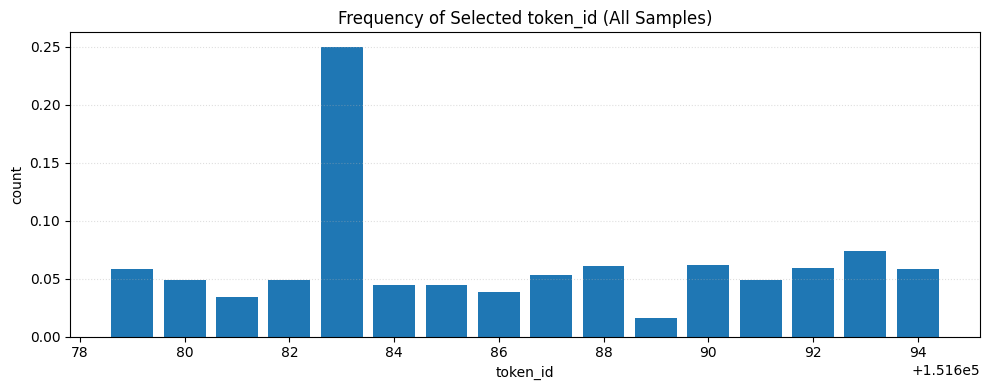

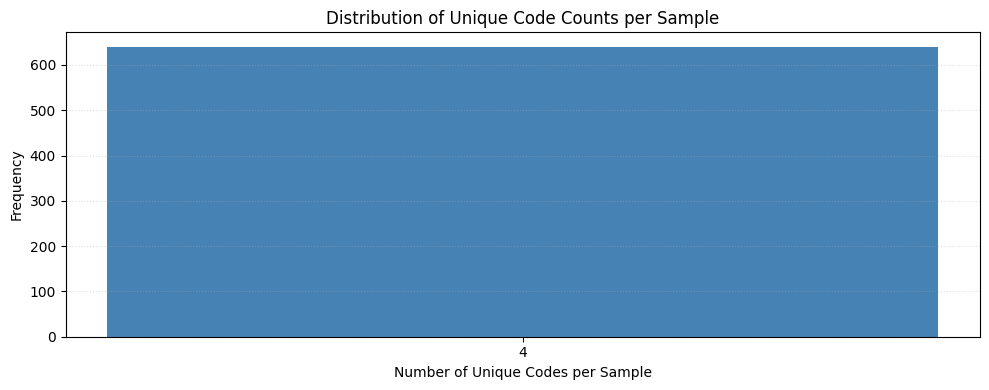

In-memory variables: all_selected_token_ids, per_sample_unique_counts


In [4]:
from typing import List

import numpy as np
import torch
import matplotlib.pyplot as plt

all_selected_token_ids: List[int] = []
per_sample_unique_counts: List[int] = []
processed_samples: int = 0

# 使用同一个 DataLoader 迭代器避免每次都从第一个批次开始（统计 10 个 batch 的全部样本）
iterator = iter(val_data)
num_iters = 20

for i in range(num_iters):
    try:
        data = next(iterator)
    except StopIteration:
        # 若耗尽，则重新创建迭代器
        iterator = iter(val_data)
        data = next(iterator)

    labels: torch.Tensor = data["labels"]
    if not isinstance(labels, torch.Tensor):
        continue

    # 样本数累计（该 batch 内全部样本）
    processed_samples += 1 if labels.dim() == 1 else int(labels.shape[0])

    # 选取有效 token（过滤 ignore_index = -100）
    valid_mask = labels != -100
    selected = labels[valid_mask]
    # 累积所有被选中的 token_id
    if selected.numel() > 0:
        all_selected_token_ids.extend(selected.cpu().tolist())

    # 统计每个样本中出现的唯一 token 个数（应在 1~4）
    if labels.dim() == 1:
        sel = labels[labels != -100]
        if sel.numel() > 0:
            per_sample_unique_counts.append(int(torch.unique(sel).numel()))
    else:
        # 按样本（batch 维度）统计
        for b in range(labels.shape[0]):
            row = labels[b]
            sel_b = row[row != -100]
            if sel_b.numel() > 0:
                per_sample_unique_counts.append(int(torch.unique(sel_b).numel()))

print(f"Processed batches: {num_iters}, samples: {processed_samples}")
print(all_selected_token_ids)
print(per_sample_unique_counts)
# 图 1：对所有选取的 token_id 绘制统计（频次）图（仅显示，不保存）
if len(all_selected_token_ids) > 0:
    token_ids, counts = np.unique(np.asarray(all_selected_token_ids, dtype=np.int64), return_counts=True)
    print(sum(counts))
    plt.figure(figsize=(10, 4))
    plt.bar(token_ids.astype(int), counts/sum(counts), width=0.8)
    plt.xlabel("token_id")
    plt.ylabel("count")
    plt.title("Frequency of Selected token_id (All Samples)")
    plt.grid(axis="y", linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()
    plt.close()

# 图 2：统计每个样本选取的独特 code 数量的分布
if len(per_sample_unique_counts) > 0:
    unique_code_counts, freq = np.unique(np.asarray(per_sample_unique_counts, dtype=np.int64), return_counts=True)
    plt.figure(figsize=(10, 4))
    plt.bar(unique_code_counts.astype(int), freq, width=0.6, color='steelblue')
    plt.xlabel("Number of Unique Codes per Sample")
    plt.ylabel("Frequency")
    plt.title("Distribution of Unique Code Counts per Sample")
    plt.xticks(unique_code_counts.astype(int))
    plt.grid(axis="y", linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()
    plt.close()

print("In-memory variables: all_selected_token_ids, per_sample_unique_counts")

In [ ]:
for i in range(num_iters):
    try:
        data = next(iterator)
    except StopIteration:
        # 若耗尽，则重新创建迭代器
        iterator = iter(val_data)
        data = next(iterator)

    labels: torch.Tensor = data["labels"]

In [1]:
import os
import random
from collections import deque
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, List

import draccus
import torch
import torch.nn as nn
import torch.distributed as dist
import tqdm
from accelerate import PartialState
from peft import LoraConfig, get_peft_model
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.cuda.amp import autocast, GradScaler
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers.models.auto.processing_auto import processor_class_from_name
from prismatic.overwatch import initialize_overwatch
import wandb
from prismatic.vla import get_latent_vla_dataset_and_collator
from prismatic.models.vlas.latent_world_vla import LatentWorldVLA, LatentWorldVLAConfig
from prismatic.util.data_utils import PaddedCollatorForActionPrediction_LIBERO
from prismatic.vla.datasets import RLDSBatchTransformLIBERO
from prismatic.vla.datasets.rlds.utils.data_utils import save_dataset_statistics
from latent_action_model.core.lam_model import load_latent_action_model
from prismatic.models.load import load_InternVL, freeze_internvl
# Sane Defaults
os.environ["TOKENIZERS_PARALLELISM"] = "false"

overwatch = initialize_overwatch(__name__)

home_path = "/mnt/project_rlinf/jlchen"
@dataclass
class FinetuneConfig:
    # fmt: off
    # Base VLM & LAM
    model_id: str = home_path + "/code/UniVLA/vla_scripts/vla_log/1006_134451+InternVL3_5-1B-Instruct-HF+lam+n8+b24+x42--run_01--image_aug/checkpoints/checkpoint-4000"
    hf_cache_dir: Optional[str] = None
    lam_path: str = home_path + "/code/UniVLA/latent_action_model/logs/nsvq_ddp/version_0/checkpoints/epoch=1.ckpt"
    vision_model_id: str = home_path + "/weights/vjepa2-vitl-fpc64-256"
    # Dataset
    data_root_dir: Path = Path(home_path + "/datasets")
    data_mix: str = "libero"
    image_resolution: int = 448
    shuffle_buffer_size: int = 2000
    image_aug: bool = False

    # Run & IO
    run_root_dir: Path = Path(__file__).resolve().parent / "latent_world_vla_log"
    # adapter_tmp_dir: Path = Path("adapter-tmp")
    # save_latest_checkpoint_only: bool = True

    # Optimization
    batch_size: int = 2
    max_steps: int = 200000
    save_steps: int = 30000
    eval_steps: int = 1000
    eval_batches: int = 100
    learning_rate: float = 1e-5
    grad_accumulation_steps: int = 16
    gradient_clip: float = 1.0
    weight_decay: float = 1e-4
    vlm_loss_weight: float = 1.0

    # Seeding & dtype
    seed: int = 42

    # LAM/codebook
    codebook_size: int = 16

    # Freezing policy (applies to InternVL)
    freeze_vision_backbone: bool = True
    freeze_projector: bool = True
    freeze_llm_backbone: bool = True
    freeze_last_llm_layer: bool = True

    # LoRA (optional)
    use_lora: bool = False
    lora_rank: int = 32
    lora_dropout: float = 0.05
    lora_alpha: int = 32
    lora_target_modules: List[str] = None  # if None, use a sensible default
    # 是否在保存时同时导出 LoRA 适配器（便于后处理融合）
    save_lora_adapter: bool = True

    # Tracking
    wandb_project: str = "finetune-LIBERO"
    wandb_entity: str = "test-project"
    run_id_note: Optional[str] = None

cfg=FinetuneConfig

print(f"Fine-tuning LatentWorldVLA on `{cfg.data_mix}` with base `{cfg.model_id}`")

# [Validate] Ensure GPU Available & Set Device / Distributed Context
assert torch.cuda.is_available(), "Fine-tuning assumes at least one GPU is available!"
distributed_state = PartialState()
torch.cuda.set_device(device_id := distributed_state.local_process_index)
torch.cuda.empty_cache()

# Seeding
torch.manual_seed(cfg.seed + device_id)
torch.cuda.manual_seed_all(cfg.seed + device_id)
random.seed(cfg.seed + device_id)

# Configure Unique Experiment ID & Log Directory
exp_id = (
    f"{cfg.model_id.split('/')[-1]}+{cfg.data_mix}"
    f"+lr-{cfg.learning_rate}"
)
if cfg.use_lora:
    exp_id += f"+lora-r{cfg.lora_rank}+dropout-{cfg.lora_dropout}"
if cfg.run_id_note is not None:
    exp_id += f"--{cfg.run_id_note}"
if cfg.image_aug:
    exp_id += "--image_aug"

# Start =>> Build Directories (hierarchical)
run_dir = cfg.run_root_dir / exp_id
ckpt_root = run_dir / "checkpoints"
log_dir = run_dir / "logs"
os.makedirs(ckpt_root, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

# Load InternVL model & tokenizer
overwatch.info(f"🔄 加载基础 InternVL `{cfg.model_id}`（HF from_pretrained）")
vlm, processor = load_InternVL(cfg.model_id, cfg.hf_cache_dir, dtype=torch.bfloat16)
tokenizer = processor.tokenizer

# Extend tokenizer with latent action special tokens and resize embeddings
overwatch.info("🔧 扩充 LLM 词表以注入动作离散 token")
special_tokens_dict = {'additional_special_tokens': [f'<ACT_{i}>' for i in range(cfg.codebook_size)]}
try:
    num_added_toks = tokenizer.add_special_tokens(special_tokens_dict)  # type: ignore[attr-defined]
except Exception:
    num_added_toks = 0
if num_added_toks > 0 and hasattr(vlm, 'resize_token_embeddings'):
    vlm.resize_token_embeddings(len(tokenizer))

# Freeze InternVL as configured
freeze_internvl(vlm, cfg.freeze_vision_backbone, cfg.freeze_projector, cfg.freeze_llm_backbone, cfg.freeze_last_llm_layer)

# Optional LoRA: attach to language_model submodules
if cfg.use_lora:
    target_modules = cfg.lora_target_modules or [
        'q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'
    ]
    lora_cfg = LoraConfig(
        r=cfg.lora_rank,
        lora_alpha=cfg.lora_alpha,
        lora_dropout=cfg.lora_dropout,
        target_modules=target_modules,
        bias="none",
        task_type="CAUSAL_LM",
    )
    # 将 LoRA 应用于整个 VLM（内部仅会匹配 target_modules）
    vlm = get_peft_model(vlm, lora_cfg)

# Load LAM
overwatch.info(
    f"🔄 加载 V-JEPA2 动作编码器与码本（ckpt=`{cfg.lam_path}`，K={cfg.codebook_size}）"
)
latent_action_model = load_latent_action_model(cfg.lam_path, vision_model_id=cfg.vision_model_id)
latent_action_model = latent_action_model.to(device_id).eval()

# Build LatentWorldVLA with config
model_cfg = LatentWorldVLAConfig()
# 根据 tokenizer 中 ACT_ token 的起始 id 校准 action_token_begin_id
act_tokens = [f"<ACT_{i}>" for i in range(cfg.codebook_size)]
act_ids = tokenizer.convert_tokens_to_ids(act_tokens)
if isinstance(act_ids, list) and len(act_ids) > 0 and min(act_ids) != -1:
    model_cfg.action_token_begin_id = min(act_ids)

overwatch.info("🔄 构建 LatentWorldVLA")
lwvla = LatentWorldVLA(
    lam=latent_action_model,
    model_cfg=model_cfg,
    vlm=vlm,
)


# 如果使用 LoRA，LatentWorldVLA 内部会对 VLM requires_grad_(False)，此处重新开启 LoRA 权重
if cfg.use_lora:
    for name, param in lwvla.vlm.named_parameters():
        if 'lora_' in name:
            param.requires_grad_(True)
    # 训练阶段启用 VLM 的 train 模式以激活 LoRA 分支（主体权重仍冻结）
    lwvla.vlm.train()

num_params = sum(p.numel() for p in lwvla.parameters())
num_trainable_params = sum(p.numel() for p in lwvla.parameters() if p.requires_grad)
overwatch.info(
    f"# LatentWorldVLA Parameters (in millions): {num_params / 10**6:.3f} Total, {num_trainable_params / 10**6:.3f} Trainable"
)

overwatch.info(
    f"🔄 构建 RLDS 数据集与 Collator(mixture=`{cfg.data_mix}`, image_res={cfg.image_resolution})"
)
train_dataset, val_dataset, tokenizer, collator = get_latent_vla_dataset_and_collator(
    cfg.data_root_dir,
    cfg.data_mix,
    latent_action_model,
    tokenizer=tokenizer,
    default_image_resolution=cfg.image_resolution,
    shuffle_buffer_size=cfg.shuffle_buffer_size,
    image_aug=cfg.image_aug,
    data_transform_fn=RLDSBatchTransformLIBERO,
    collator_fn=PaddedCollatorForActionPrediction_LIBERO,
)
# [Important] Save Dataset Statistics =>> used to de-normalize actions for inference!
if distributed_state.is_main_process:
    save_dataset_statistics(train_dataset.dataset_statistics, run_dir)

# DDP
lwvla = lwvla.to(device_id)
wrapped_model = DDP(lwvla, device_ids=[device_id], find_unused_parameters=True, gradient_as_bucket_view=True)

# Optimizer & LR scheduler
trainable_params = [param for param in wrapped_model.parameters() if param.requires_grad]
optimizer = AdamW(trainable_params, lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=int(cfg.max_steps * 0.8), gamma=0.1)

# DataLoader
dataloader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    sampler=None,
    collate_fn=collator,
    num_workers=0,  # RLDS 内部并行
)

2025-10-27 17:00:22.563321: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-27 17:00:22.605076: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-27 17:00:22.605096: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-27 17:00:22.606141: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-27 17:00:22.612978: I tensorflow/core/platform/cpu_feature_guar

KeyboardInterrupt: 

In [46]:
from transformers import AutoVideoProcessor, AutoModel

hf_repo = "/mnt/project_rlinf/jlchen/weights/vjepa2-vitl-fpc64-256"

model = AutoModel.from_pretrained(hf_repo,device_map="cuda")
processor = AutoVideoProcessor.from_pretrained(hf_repo)

In [51]:
import torch
video = torch.rand(5,3, 512, 512)  # 1帧示例
video_inputs = processor(video, return_tensors="pt").to(model.device)
print(video_inputs['pixel_values_videos'].shape)
# print(video_inputs.keys())
with torch.no_grad():
    video_embeddings = model.get_vision_features(**video_inputs)

print(video_embeddings.shape)
# print(video_embeddings.sum(-1))

torch.Size([1, 5, 3, 256, 256])
torch.Size([1, 512, 1024])


In [52]:
from transformers.processing_utils import VideosKwargs


video_1 = video[:,:5,:,:]
video_inputs_1 = processor(video_1, return_tensors="pt").to(model.device)
with torch.no_grad():
    video_embeddings_1 = model.get_vision_features(**video_inputs_1)

print(video_embeddings_1.mean())
print(video_embeddings.mean())

tensor(0.0573, device='cuda:0')
tensor(0.0573, device='cuda:0')


In [ ]:
import numpy as np
arr = np.linspace(0, 18, 5)
print(arr)
print(np.round(arr))
print(arr.astype(int))
# -> [0., 1., 1., 2., 2., 3.]


[ 0.    3.75  7.5  11.25 15.  ]
[ 0.  4.  8. 11. 15.]
[ 0  3  7 11 15]


In [7]:
import torch
from latent_action_model.core.utils.dpt_head import DPTHead
x = [torch.randn(2, 256, 1024), torch.randn(2, 256, 1024), torch.randn(2, 256, 1024), torch.randn(2, 256, 1024)]
head = DPTHead(in_channels=1024, grid_size=16, lvl=0)
y = head(x)
y.shape



torch.Size([2, 256, 32, 32])

In [1]:
import torch
from latent_action_model.core.utils.modules import build_action_block_causal_attention_mask
# 参数
T, H, W, add_tokens = 3, 2, 2, 2
N_T = add_tokens + H * W
N = T * N_T

# 自定义 block mask (True=可见)
custom_mask = build_action_block_causal_attention_mask(T, H, W, add_tokens)



# 可视化
print("Custom mask (对于F.sdpa，True=关注；对于其他的，True=屏蔽):")
print((custom_mask).int())

Custom mask (对于F.sdpa，True=关注；对于其他的，True=屏蔽):
tensor([[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [6]:
from latent_action_model.core.utils.modules import build_modal_block_attention_mask, build_decoder_block_attention_mask
block_mask = build_modal_block_attention_mask(T, H, W, add_tokens=1, ar_query=False, num_queries=2)
print(block_mask.int())
# print((~block_mask | ~custom_mask).int())

tensor([[1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
        [1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
        [1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 

In [ ]:
dec_mask=build_decoder_block_attention_mask(T, H, W, add_tokens=1, is_causal=True)
print(dec_mask.int())


tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=torch.int32)
